In [2]:
pip install google-play-scraper

Note: you may need to restart the kernel to use updated packages.


In [29]:
# Install once

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
pip install selenium webdriver-manager pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [11]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

cities = [
    "hyderabad", "bangalore", "mumbai", "delhi",
    "chennai", "pune", "kolkata", "ahmedabad",
    "jaipur", "lucknow", "kochi"
]

all_data = []

for city in cities:
    print(f"Scraping {city}...")

    url = f"https://www.practo.com/{city}/doctors"
    driver.get(url)
    time.sleep(5)

    # Scroll
    for _ in range(20):
        driver.execute_script("window.scrollBy(0, 2000);")
        time.sleep(2)

    cards = driver.find_elements(By.XPATH, "//div[contains(@class,'info-section')]")
    print(f"{len(cards)} doctors found")

    for card in cards:

        # Name
        try:
            name = card.find_element(By.XPATH, ".//h2").text
        except:
            name = None

        # Hospital
        try:
            hospital = card.find_element(
                By.XPATH, ".//span[@data-qa-id='doctor_clinic_name']"
            ).text
        except:
            hospital = None

        # Location
        try:
            location = card.find_element(
                By.XPATH, ".//p[contains(@class,'location-text')]"
            ).text
        except:
            location = city

        # Specialization
        try:
            specialization = card.find_element(
                By.XPATH, ".//div[contains(@class,'u-d-flex')]"
            ).text
        except:
            specialization = None

        # Experience (digits only)
        try:
            exp_text = card.find_element(
                By.XPATH, ".//div[@data-qa-id='doctor_experience']"
            ).text
            experience = int(re.search(r'\d+', exp_text).group())
        except:
            experience = None

        # Fee
        try:
            fee_text = card.find_element(
                By.XPATH, ".//*[contains(text(),'₹')]"
            ).text
            fee = int(re.search(r'\d+', fee_text).group())
        except:
            fee = None

        # Rating
        try:
            rating_text = card.find_element(
                By.XPATH, ".//*[@data-qa-id='doctor_recommendation']"
            ).text
            rating = int(re.search(r'\d+', rating_text).group())
        except:
            rating = None

        # Reviews (FIXED)
        try:
            review_text = card.find_element(
                By.XPATH, ".//*[@data-qa-id='total_feedback']"
            ).text  # "70 Patient Stories"

            reviews = int(re.search(r'\d+', review_text).group())
        except:
            reviews = None

        all_data.append({
            "Doctor_Name": name,
            "Hospital_Name": hospital,
            "City": location,
            "Specialization": specialization,
            "Experience_in_years": experience,
            "Consultation_Fee": fee,
            "Patient_Rating": rating,
            "Reviews": reviews,
            "Source": "Practo"
        })

    print(f"Collected so far: {len(all_data)}")

driver.quit()

df = pd.DataFrame(all_data)

print("Total records:", len(df))

df.to_csv("practo_1000_plus.csv", index=False)

Scraping hyderabad...
150 doctors found
Collected so far: 150
Scraping bangalore...
59 doctors found
Collected so far: 209
Scraping mumbai...
180 doctors found
Collected so far: 389
Scraping delhi...
59 doctors found
Collected so far: 448
Scraping chennai...
150 doctors found
Collected so far: 598
Scraping pune...
180 doctors found
Collected so far: 778
Scraping kolkata...
180 doctors found
Collected so far: 958
Scraping ahmedabad...
90 doctors found
Collected so far: 1048
Scraping jaipur...
180 doctors found
Collected so far: 1228
Scraping lucknow...
90 doctors found
Collected so far: 1318
Scraping kochi...
0 doctors found
Collected so far: 1318
Total records: 1318


### Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("practo_1000_plus.csv")

# Preview
print(df.head())
df.info()
df.describe()

                  Doctor_Name                             Hospital_Name  \
0    Dr. Chandrashekhar Reddy                   Sri Sai Dental Hospital   
1      Dr. M. S. Sushma Susik                Brite Smiles Dental Clinic   
2              Dr. Vikas Gowd                 Dr.Gowds Dental Hospitals   
3         Dr. Pallavi G Pawar                   Sri Sai Dental Hospital   
4  Dr. Syed Saood Hasan Razvi  Denta'Glo Dental Clinic & Implant Centre   

        City Specialization  Experience_in_years  Consultation_Fee  \
0  hyderabad        Dentist                   27             400.0   
1  hyderabad        Dentist                   35             300.0   
2  hyderabad        Dentist                   27             500.0   
3  hyderabad        Dentist                   22             400.0   
4  hyderabad        Dentist                   20             300.0   

   Patient_Rating  Reviews  Source  
0            95.0     58.0  Practo  
1            97.0    777.0  Practo  
2            98.0

,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews
count,1318.000000,1307.000000,1126.000000,1111.000000
mean,23.491654,877.453711,90.388988,160.942394
std,9.534472,528.215185,14.013696,418.227450
min,2.000000,5.000000,20.000000,1.000000
25%,17.000000,500.000000,88.000000,5.000000
50%,22.000000,800.000000,96.000000,24.000000
75%,28.000000,1000.000000,100.000000,125.500000
max,59.000000,5400.000000,100.000000,5039.000000


### Identifying Missing values

In [2]:
print(df.isnull().sum()/len(df))

# Drop rows where key fields are missing
df.dropna(subset=['Specialization'], inplace=True)

Doctor_Name            0.000000
Hospital_Name          0.000000
City                   0.000000
Specialization         0.003035
Experience_in_years    0.000000
Consultation_Fee       0.008346
Patient_Rating         0.145675
Reviews                0.157056
Source                 0.000000
dtype: float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1314 entries, 0 to 1317
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1314 non-null   object 
 1   Hospital_Name        1314 non-null   object 
 2   City                 1314 non-null   object 
 3   Specialization       1314 non-null   object 
 4   Experience_in_years  1314 non-null   int64  
 5   Consultation_Fee     1303 non-null   float64
 6   Patient_Rating       1124 non-null   float64
 7   Reviews              1109 non-null   float64
 8   Source               1314 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 102.7+ KB


### Handling Missing values

In [4]:
df["Consultation_Fee"] = df["Consultation_Fee"].fillna(df["Consultation_Fee"].mean())
df["Patient_Rating"] = df["Patient_Rating"].fillna(df["Patient_Rating"].mean())
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].mean())

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1314 entries, 0 to 1317
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1314 non-null   object 
 1   Hospital_Name        1314 non-null   object 
 2   City                 1314 non-null   object 
 3   Specialization       1314 non-null   object 
 4   Experience_in_years  1314 non-null   int64  
 5   Consultation_Fee     1314 non-null   float64
 6   Patient_Rating       1314 non-null   float64
 7   Reviews              1314 non-null   float64
 8   Source               1314 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 102.7+ KB


### Removing Duplicates

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1313 entries, 0 to 1317
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Doctor_Name          1313 non-null   object 
 1   Hospital_Name        1313 non-null   object 
 2   City                 1313 non-null   object 
 3   Specialization       1313 non-null   object 
 4   Experience_in_years  1313 non-null   int64  
 5   Consultation_Fee     1313 non-null   float64
 6   Patient_Rating       1313 non-null   float64
 7   Reviews              1313 non-null   float64
 8   Source               1313 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 102.6+ KB


### Converting DataTypes

In [8]:
df["Reviews"] = df["Reviews"].fillna(0).astype(int)

In [9]:
df.head()

,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Source
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58,Practo
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777,Practo
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107,Practo
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5,Practo
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251,Practo


### Outlier Detection

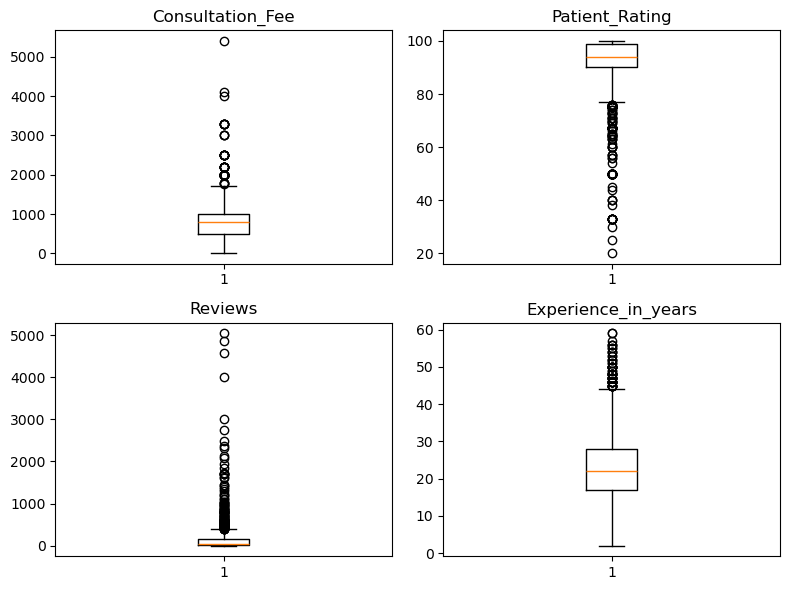

In [10]:
num_cols = ["Consultation_Fee", "Patient_Rating", "Reviews", "Experience_in_years"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes = axes.flatten()  # makes indexing easier

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Handling Outliers

In [11]:
df.to_csv("practo_1000_plus_cleaned.csv", index=False)

In [11]:
df.columns

Index(['Doctor_Name', 'Hospital_Name', 'City', 'Specialization',
       'Experience_in_years', 'Consultation_Fee', 'Patient_Rating', 'Reviews',
       'Source'],
      dtype='object')

In [13]:
df["Hospital_Name"].nunique()

551